<a href="https://colab.research.google.com/github/Ginkno/postech-tech-challenge-fase2-grupo1-12dtat/blob/Elizabeth/notebooks/03_modelagem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Modelagem

**Dimensão 5 da rúbrica — 20 pontos.**

Mínimo de **dois** classificadores distintos. Um único modelo zera 8 dos 20 pontos.

In [109]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

RAW_1 = Path("../data/raw/application_record.csv")
RAW_2 = Path("../data/raw/credit_record.csv")

DATASET_T = Path("../data/processed/dataset_tratado.csv")
PROCESSED_X = Path("../data/processed/dataset_processed_x.csv")
TARGET = "IS_BAD_PAYER"

pd.set_option("display.max_columns", None)

In [123]:
df_model = pd.read_csv(DATASET_T)
df_model_x = pd.read_csv(PROCESSED_X)

In [111]:
display(df_model.head())

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_INACTIVE,YEARS_EMPLOYED,TOTAL_MOUNTHS_OBSERVED,STATUS_LATED,STATUS_ON_TIME,STATUS_NO_CREDIT,WORST_LATE_HISTORY,IS_BAD_PAYER,INCOME_PER_PERSON,HAS_CHILDREN,PROP_LATED,PROP_ON_TIME,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff
0,1,1,1,0,427500.0,1,1,0,0,2.0,32,0,12,16,2,13,1,2,1,213750.0,0,0.125000,0.812500,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,1,1,0,427500.0,1,1,0,0,2.0,32,0,12,15,2,12,1,2,1,213750.0,0,0.133333,0.800000,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,1,1,1,0,112500.0,1,0,0,0,2.0,58,0,3,30,7,7,16,1,0,56250.0,0,0.233333,0.233333,False,False,False,True,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,0,0,1,0,270000.0,1,0,1,1,1.0,52,0,8,5,2,0,3,1,0,270000.0,0,0.400000,0.000000,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
4,0,0,1,0,270000.0,1,0,1,1,1.0,52,0,8,5,0,0,5,0,0,270000.0,0,0.000000,0.000000,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


In [ ]:
# Resampling com sklearn.utils, aplicado somente aos dados de treino.
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# WORST_LATE_HISTORY permanece conforme solicitado, mas vaza informacao do alvo.
colunas_excluidas = [
    "ID",
    TARGET,
    "FLAG_PHONE"
    "FLAG_WORK_PHONE",
    "YEARS_EMPLOYED",
    "CNT_CHILDREN",
    "WORST_LATE_HISTORY"
]
X_balanceamento = df_model_x.drop(columns=colunas_excluidas, errors="ignore")
y_balanceamento = df_model_x[TARGET]

X_balanceamento_treino, X_balanceamento_teste, y_balanceamento_treino, y_balanceamento_teste = train_test_split(
    X_balanceamento,
    y_balanceamento,
    test_size=0.2,
    stratify=y_balanceamento,
    random_state=RANDOM_STATE,
)

df_treino_balanceamento = X_balanceamento_treino.copy()
df_treino_balanceamento[TARGET] = y_balanceamento_treino

df_teste_balanceamento = X_balanceamento_teste.copy()
df_teste_balanceamento[TARGET] = y_balanceamento_teste

proporcao_minoria = 3 / 7  # 30% minoria para 70% maioria


def criar_dataframe_balanceado(df_treino, target, metodo):
    contagens = df_treino[target].value_counts()
    if len(contagens) != 2:
        raise ValueError("O resampling implementado espera exatamente duas classes.")

    classe_majoritaria = contagens.idxmax()
    classe_minoritaria = contagens.idxmin()
    dados_majoritarios = df_treino[df_treino[target] == classe_majoritaria]
    dados_minoritorios = df_treino[df_treino[target] == classe_minoritaria]

    if metodo == "undersampling":
        quantidade_majoritaria = round(len(dados_minoritorios) / proporcao_minoria)
        dados_majoritarios = resample(
            dados_majoritarios,
            replace=False,
            n_samples=quantidade_majoritaria,
            random_state=RANDOM_STATE,
        )
    elif metodo == "oversampling":
        quantidade_minoritaria = round(len(dados_majoritarios) * proporcao_minoria)
        dados_minoritorios = resample(
            dados_minoritorios,
            replace=True,
            n_samples=quantidade_minoritaria,
            random_state=RANDOM_STATE,
        )
    else:
        raise ValueError("Metodo deve ser 'undersampling' ou 'oversampling'.")

    df_balanceado = pd.concat([dados_majoritarios, dados_minoritorios])
    return resample(
        df_balanceado,
        replace=False,
        n_samples=len(df_balanceado),
        random_state=RANDOM_STATE,
    ).reset_index(drop=True)


df_balanceado_under_70_30 = criar_dataframe_balanceado(
    df_treino_balanceamento, TARGET, metodo="undersampling"
)
df_balanceado_over_70_30 = criar_dataframe_balanceado(
    df_treino_balanceamento, TARGET, metodo="oversampling"
)

print("Features usadas:", list(X_balanceamento.columns))
print("Distribuicao original do treino:")
display(df_treino_balanceamento[TARGET].value_counts(normalize=True).sort_index())
print("Distribuicao com undersampling (aprox. 70/30):")
display(df_balanceado_under_70_30[TARGET].value_counts(normalize=True).sort_index())
print("Distribuicao com oversampling (aprox. 70/30):")
display(df_balanceado_over_70_30[TARGET].value_counts(normalize=True).sort_index())
print(f"Teste mantido sem resampling: {len(df_teste_balanceamento)} linhas")

Features usadas: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'YEARS_BIRTH', 'IS_INACTIVE', 'TOTAL_MOUNTHS_OBSERVED', 'STATUS_LATED', 'STATUS_ON_TIME', 'STATUS_NO_CREDIT', 'WORST_LATE_HISTORY', 'INCOME_PER_PERSON', 'HAS_CHILDREN', 'PROP_LATED', 'PROP_ON_TIME']
Distribuicao original do treino:


IS_BAD_PAYER
0    0.88229
1    0.11771
Name: proportion, dtype: float64

Distribuicao com undersampling (aprox. 70/30):


IS_BAD_PAYER
0    0.699991
1    0.300009
Name: proportion, dtype: float64

Distribuicao com oversampling (aprox. 70/30):


IS_BAD_PAYER
0    0.7
1    0.3
Name: proportion, dtype: float64

Teste mantido sem resampling: 7292 linhas


In [113]:
df_model_x.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_INACTIVE,YEARS_EMPLOYED,TOTAL_MOUNTHS_OBSERVED,STATUS_LATED,STATUS_ON_TIME,STATUS_NO_CREDIT,WORST_LATE_HISTORY,INCOME_PER_PERSON,HAS_CHILDREN,PROP_LATED,PROP_ON_TIME,IS_BAD_PAYER
0,5008804,1,1,1,0,427500.0,4,1,0,4,1,1,0,0,17,2.0,32,0,12,16,2,13,1,2,213750.0,0,0.125000,0.812500,1
1,5008805,1,1,1,0,427500.0,4,1,0,4,1,1,0,0,17,2.0,32,0,12,15,2,12,1,2,213750.0,0,0.133333,0.800000,1
2,5008806,1,1,1,0,112500.0,4,4,1,1,1,0,0,0,16,2.0,58,0,3,30,7,7,16,1,56250.0,0,0.233333,0.233333,0
3,5008808,0,0,1,0,270000.0,0,4,3,1,1,0,1,1,14,1.0,52,0,8,5,2,0,3,1,270000.0,0,0.400000,0.000000,0
4,5008809,0,0,1,0,270000.0,0,4,3,1,1,0,1,1,14,1.0,52,0,8,5,0,0,5,0,270000.0,0,0.000000,0.000000,0


## 1. Split treino/teste

`stratify` preserva a proporção das classes nos dois conjuntos.

In [114]:
# Reutilizar o split da celula 6 e manter somente as duas features selecionadas.
X = X_balanceamento
y = y_balanceamento
X_train = X_balanceamento_treino
X_test = X_balanceamento_teste
y_train = y_balanceamento_treino
y_test = y_balanceamento_teste

print(f'Shape de X_train: {X_train.shape}')
print(f'Shape de X_test: {X_test.shape}')
print(f'Shape de y_train: {y_train.shape}')
print(f'Shape de y_test: {y_test.shape}')

print('\nDistribuição da variável alvo no treino:')
display(y_train.value_counts(normalize=True))

print('\nDistribuição da variável alvo no teste:')
display(y_test.value_counts(normalize=True))

Shape de X_train: (29165, 24)
Shape de X_test: (7292, 24)
Shape de y_train: (29165,)
Shape de y_test: (7292,)

Distribuição da variável alvo no treino:


IS_BAD_PAYER
0    0.88229
1    0.11771
Name: proportion, dtype: float64


Distribuição da variável alvo no teste:


IS_BAD_PAYER
0    0.882337
1    0.117663
Name: proportion, dtype: float64

## 2. Modelos candidatos

Usar `Pipeline` evita vazamento: o scaler é ajustado só no fold de treino durante a validação cruzada.

In [115]:
import numpy as np

# Calcular scale_pos_weight para lidar com o desbalanceamento de classes
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count

print(f"Scale Pos Weight calculado: {scale_pos_weight_value:.2f}")

Scale Pos Weight calculado: 7.50


In [116]:
from sklearn.preprocessing import MinMaxScaler

# Cada modelo recebe sua propria instancia; o scaler ajusta min/max no treino de cada fit/fold.
def criar_minmax_scaler():
    return MinMaxScaler(feature_range=(0, 1))

In [117]:
import numpy as np
import pandas as pd
import sklearn
import lightgbm
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.utils.validation import check_is_fitted
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

modelos = {
    "logistic_regression": Pipeline([
        ("scaler", criar_minmax_scaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "random_forest": Pipeline([
        ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "svm": Pipeline([
        ("scaler", criar_minmax_scaler()),
        ("clf", SVC(class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "knn": Pipeline([
        ("scaler", criar_minmax_scaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5, weights="distance", n_jobs=-1)),
    ]),
    "kmeans": Pipeline([
        ("scaler", criar_minmax_scaler()),
        ("clf", KMeansMajorityClassifier(n_clusters=2, random_state=RANDOM_STATE, n_init=10)),
    ]),
    "xgboost": Pipeline([
        ("clf", XGBClassifier(scale_pos_weight=scale_pos_weight_value, random_state=RANDOM_STATE, eval_metric="logloss")),
    ]),
    "lightgbm": Pipeline([
        ("clf", LGBMClassifier(scale_pos_weight=scale_pos_weight_value, random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
}

[LightGBM] [Info] Number of positive: 3433, number of negative: 8010
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001353 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1205
[LightGBM] [Info] Number of data points in the train set: 11443, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300009 -> initscore=-0.847256
[LightGBM] [Info] Start training from score -0.847256
[LightGBM] [Info] Number of positive: 11028, number of negative: 25732
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001484 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1208
[LightGBM] [Info] Number of data points in the train set: 36760, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300000 -> initscore=-0.847298
[Lig

,estrategia,modelo,accuracy,roc_auc,f1_mau_pagador,precisao_mau_pagador,recall_mau_pagador,balanced_accuracy
0,oversampling_70_30,random_forest,0.909490,0.866567,0.436860,0.815287,0.298368,0.644677
1,oversampling_70_30,lightgbm,0.528113,0.804393,0.312762,0.188720,0.912587,0.694715
2,oversampling_70_30,xgboost,0.636039,0.803146,0.338155,0.215102,0.790210,0.702845
3,oversampling_70_30,svm,0.681980,0.779187,0.355296,0.233297,0.744755,0.709182
4,oversampling_70_30,logistic_regression,0.664290,0.744614,0.325991,0.213410,0.689977,0.675420
5,oversampling_70_30,knn,0.840510,0.737870,0.429622,0.370872,0.510490,0.697505
6,oversampling_70_30,kmeans,0.882337,0.500000,0.000000,0.000000,0.000000,0.500000
7,undersampling_70_30,random_forest,0.870680,0.846835,0.459599,0.452086,0.467366,0.695915
8,undersampling_70_30,xgboost,0.593390,0.805263,0.336837,0.208414,0.877622,0.716554
9,undersampling_70_30,lightgbm,0.498354,0.802858,0.306146,0.182827,0.940559,0.689972


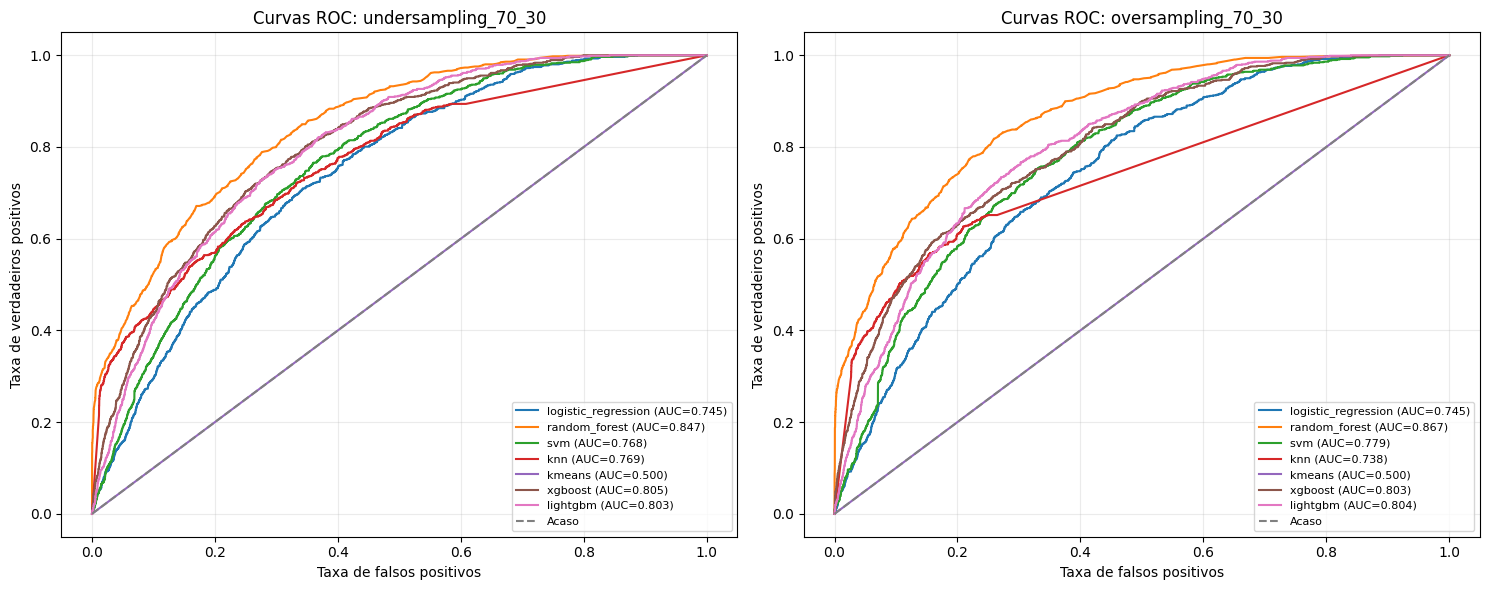

In [ ]:
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# Reutiliza os modelos definidos na celula 12 e os conjuntos da celula 6.
datasets_resample_celula_6 = {
    "undersampling_70_30": df_balanceado_under_70_30,
    "oversampling_70_30": df_balanceado_over_70_30,
}

X_teste_balanceamento = df_teste_balanceamento.drop(columns=[TARGET])
y_teste_balanceamento = df_teste_balanceamento[TARGET]

resultados_resampling = []
modelos_treinados_resampling = {}
curvas_roc_resampling = {}

for estrategia, df_treino in datasets_resample_celula_6.items():
    X_treino = df_treino.drop(columns=[TARGET])
    y_treino = df_treino[TARGET]

    for nome_modelo, pipeline_celula_12 in modelos.items():
        pipeline_treinado = clone(pipeline_celula_12)
        pipeline_treinado.fit(X_treino, y_treino)
        previsoes = pipeline_treinado.predict(X_teste_balanceamento)

        if hasattr(pipeline_treinado, "predict_proba"):
            scores_positivos = pipeline_treinado.predict_proba(X_teste_balanceamento)[:, 1]
        elif hasattr(pipeline_treinado, "decision_function"):
            scores_positivos = pipeline_treinado.decision_function(X_teste_balanceamento)
        else:
            # KMeansMajorityClassifier so fornece classe prevista; sua ROC tem resolucao limitada.
            scores_positivos = previsoes

        fpr, tpr, limiares = roc_curve(y_teste_balanceamento, scores_positivos)
        auc = roc_auc_score(y_teste_balanceamento, scores_positivos)
        curvas_roc_resampling[(estrategia, nome_modelo)] = (fpr, tpr, auc)

        modelos_treinados_resampling[(estrategia, nome_modelo)] = pipeline_treinado
        resultados_resampling.append({
            "estrategia": estrategia,
            "modelo": nome_modelo,
            "accuracy": accuracy_score(y_teste_balanceamento, previsoes),
            "roc_auc": auc,
            "f1_mau_pagador": f1_score(y_teste_balanceamento, previsoes, zero_division=0),
            "precisao_mau_pagador": precision_score(y_teste_balanceamento, previsoes, zero_division=0),
            "recall_mau_pagador": recall_score(y_teste_balanceamento, previsoes, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_teste_balanceamento, previsoes),
        })

resultados_resampling = pd.DataFrame(resultados_resampling).sort_values(
    by=["estrategia", "roc_auc"],
    ascending=[True, False],
).reset_index(drop=True)

display(resultados_resampling)

fig, axes = plt.subplots(1, len(datasets_resample_celula_6), figsize=(15, 6), squeeze=False)
for eixo, estrategia in zip(axes.ravel(), datasets_resample_celula_6):
    for (estrategia_curva, nome_modelo), (fpr, tpr, auc) in curvas_roc_resampling.items():
        if estrategia_curva == estrategia:
            eixo.plot(fpr, tpr, label=f"{nome_modelo} (AUC={auc:.3f})")

    eixo.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Acaso")
    eixo.set_title(f"Curvas ROC: {estrategia}")
    eixo.set_xlabel("Taxa de falsos positivos")
    eixo.set_ylabel("Taxa de verdadeiros positivos")
    eixo.legend(loc="lower right", fontsize=8)
    eixo.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [125]:
from pathlib import Path

pasta_resultados = Path("../data/processed/")
pasta_resultados.mkdir(parents=True, exist_ok=True)

caminho_metricas = pasta_resultados / "resultados_resampling.csv"
caminho_previsoes = pasta_resultados / "previsoes_resampling.csv"
caminho_importancias = pasta_resultados / "importancias_resampling.csv"

resultados_resampling.to_csv(caminho_metricas, index=False)

ids_teste = df_model_x.loc[X_teste_balanceamento.index, "ID"]
linhas_previsoes = []
linhas_importancias = []

for (estrategia, nome_modelo), pipeline_treinado in modelos_treinados_resampling.items():
    previsoes = pipeline_treinado.predict(X_teste_balanceamento)
    if hasattr(pipeline_treinado, "predict_proba"):
        scores = pipeline_treinado.predict_proba(X_teste_balanceamento)[:, 1]
    elif hasattr(pipeline_treinado, "decision_function"):
        scores = pipeline_treinado.decision_function(X_teste_balanceamento)
    else:
        scores = previsoes

    linhas_previsoes.extend({
        "estrategia": estrategia,
        "modelo": nome_modelo,
        "ID": cliente_id,
        "y_true": valor_real,
        "y_pred": valor_previsto,
        "score_mau_pagador": score,
    } for cliente_id, valor_real, valor_previsto, score in zip(
        ids_teste.to_numpy(),
        y_teste_balanceamento.to_numpy(),
        previsoes,
        scores,
    ))

    classificador = pipeline_treinado.named_steps["clf"]
    if hasattr(classificador, "feature_importances_"):
        importancias = classificador.feature_importances_
        metodo_importancia = "feature_importances_"
    elif hasattr(classificador, "coef_"):
        importancias = np.abs(classificador.coef_).mean(axis=0)
        metodo_importancia = "coeficiente_abs_medio"
    else:
        continue

    linhas_importancias.extend({
        "estrategia": estrategia,
        "modelo": nome_modelo,
        "variavel": variavel,
        "importancia": importancia,
        "metodo": metodo_importancia,
    } for variavel, importancia in zip(X_teste_balanceamento.columns, importancias))

pd.DataFrame(linhas_previsoes).to_csv(caminho_previsoes, index=False)
pd.DataFrame(linhas_importancias).to_csv(caminho_importancias, index=False)

print(f"Metricas exportadas: {caminho_metricas}")
print(f"Previsoes exportadas: {caminho_previsoes}")
print(f"Importancias exportadas: {caminho_importancias}")

Metricas exportadas: ../data/processed/resultados_resampling.csv
Previsoes exportadas: ../data/processed/previsoes_resampling.csv
Importancias exportadas: ../data/processed/importancias_resampling.csv


## 3. Validação cruzada

In [119]:
from sklearn.model_selection import cross_val_score
import pandas as pd
from scipy import stats

all_model_scores = {}

for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring="f1")
    all_model_scores[nome] = scores # Armazena os scores de cada fold
    print(f"{nome}: {scores.mean().round(4)}")

logistic_regression: 0.3192
random_forest: 0.3421
svm: 0.3377
knn: 0.3938
kmeans: 0.0
xgboost: 0.3956
[LightGBM] [Info] Number of positive: 2747, number of negative: 20585
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001834 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1247
[LightGBM] [Info] Number of data points in the train set: 23332, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.117735 -> initscore=-2.014053
[LightGBM] [Info] Start training from score -2.014053
[LightGBM] [Info] Number of positive: 2747, number of negative: 20585
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002226 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1246
[LightGBM] [Info] Number of data points in the train set: 23332, number of 

## 4. Comparação

Os resultados desta execução precisam ser recalculados após as alterações nas features. Além disso, `WORST_LATE_HISTORY` é usado diretamente para construir `IS_BAD_PAYER`; incluí-lo como preditor causa vazamento do alvo. Portanto, métricas obtidas com essa feature não devem ser interpretadas como desempenho real de generalização. Para uma avaliação válida, remova `WORST_LATE_HISTORY` de `X` e mantenha apenas variáveis disponíveis antes da classificação.

Teste T Pareado para Comparação de Modelos
Vamos realizar um teste t pareado entre os scores do XGBoost e do LightGBM para verificar se a diferença observada é estatisticamente significativa.

In [120]:
from scipy import stats

# Obter os scores dos dois modelos a serem comparados
scores_xgboost = all_model_scores['xgboost']
scores_lightgbm = all_model_scores['lightgbm']

# Realizar o teste t pareado
# O parâmetro 'alternative' define o tipo de teste (two-sided, less, greater)
# Aqui, 'two-sided' verifica se há uma diferença significativa em qualquer direção.
t_statistic, p_value = stats.ttest_rel(scores_xgboost, scores_lightgbm, alternative='greater')

print(f"F1-scores XGBoost: {scores_xgboost}")
print(f"F1-scores LightGBM: {scores_lightgbm}")
print(f"Estatística t: {t_statistic:.4f}")
print(f"Valor p: {p_value:.4f}")

# Interpretação do resultado
alpha = 0.05 # Nível de significância

if p_value < alpha:
    print(f"Com p-valor ({p_value:.4f}) menor que {alpha}, podemos rejeitar a hipótese nula.")
    print("Isso sugere que o XGBoost tem um F1-score significativamente maior que o LightGBM.")
else:
    print(f"Com p-valor ({p_value:.4f}) maior que {alpha}, não temos evidências suficientes para rejeitar a hipótese nula.")
    print("A diferença observada nos F1-scores entre XGBoost e LightGBM pode ser devido ao acaso (ruído).")

F1-scores XGBoost: [0.39187228 0.41360037 0.39092664 0.3956044  0.38579655]
F1-scores LightGBM: [0.38591233 0.37297093 0.36169401 0.37103397 0.37331277]
Estatística t: 3.6812
Valor p: 0.0106
Com p-valor (0.0106) menor que 0.05, podemos rejeitar a hipótese nula.
Isso sugere que o XGBoost tem um F1-score significativamente maior que o LightGBM.


A conclusão estatística anterior foi baseada em resultados de uma configuração anterior e não deve ser reutilizada. Mesmo após recalcular os modelos, um teste comparativo com `WORST_LATE_HISTORY` como feature é inválido para estimar generalização, pois essa variável participa diretamente da definição do alvo. Refaça a comparação e o teste estatístico somente após remover essa coluna das features.

## 5. Treinamento do Modelo Final e Salvamento

O modelo final deve ser definido somente após selecionar uma configuração com avaliação válida. Não use resultados obtidos com `WORST_LATE_HISTORY` como preditor, pois essa coluna é usada para gerar `IS_BAD_PAYER` e causa vazamento do alvo.

In [121]:
import joblib

# Selecionar o pipeline do XGBoost do dicionário 'modelos'
final_model_pipeline = modelos['xgboost']

# Treinar o modelo no conjunto completo de treinamento
print("Treinando o modelo XGBoost final...")
final_model_pipeline.fit(X_train, y_train)
print("Treinamento concluído.")

# Salvar o modelo treinado
model_filename = 'final_xgboost_model.pkl'
joblib.dump(final_model_pipeline, model_filename)
print(f"Modelo final salvo como {model_filename}")

# Você pode carregar o modelo no notebook 04 usando:
# loaded_model = joblib.load('final_xgboost_model.pkl')

Treinando o modelo XGBoost final...
Treinamento concluído.
Modelo final salvo como final_xgboost_model.pkl
